In [ ]:
# Cell 0 — Install system & Python dependencies
!apt-get install -y tesseract-ocr -q
!pip install pytesseract scikit-learn seaborn --quiet


Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


In [ ]:
# Cell 1 — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Cell 2 — Verify Drive contents
import os
print('Drive root:', os.listdir('/content/drive/MyDrive'))


Drive root: ['food_dataset', 'DMT.ipynb']


In [ ]:
# Cell 3 — List food_dataset folder
print('food_dataset:', os.listdir('/content/drive/MyDrive/food_dataset')[:20])


food_dataset: ['archive (1)']


In [ ]:
# Cell 4 — Count images per class folder
dataset_path = '/content/drive/MyDrive/food_dataset/archive (1)'
class_folders = sorted(os.listdir(dataset_path))
print(f'Found {len(class_folders)} class folders:')
for i, folder in enumerate(class_folders, 1):
    count = len(os.listdir(os.path.join(dataset_path, folder)))
    print(f'  {i:2d}. {folder:<35} {count} images')


Found 15 class folders:
   1. Biryani-resize                      1 images
   2. Chole-Bhature-Resized               1 images
   3. Jalebi-Resize                       1 images
   4. Kofta-Resized                       1 images
   5. Naan-Resized                        1 images
   6. Paneer-Tikka-resized                1 images
   7. Pani-Puri-resize                    1 images
   8. Pav-Bhaji-Resized                   1 images
   9. Vadapav-Resized                     1 images
  10. dabeli-resize                       1 images
  11. dal_resized                         1 images
  12. dhokla-resize                       1 images
  13. dosa_resized                        1 images
  14. kathi-resize                        1 images
  15. pakora-resize                       1 images


In [ ]:
# Cell 5 — Imports
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import pytesseract
from PIL import Image

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
# CRITICAL: use MobileNetV2's own preprocessor (scales pixels to [-1, 1])
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print('TensorFlow version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU available:', gpus)


TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Cell 6 — OCR helper functions (used for nutrition label scanning)
import cv2

def extract_text(img):
    """Convert PIL image → grayscale → threshold → OCR text."""
    img_cv = np.array(img)
    img_cv = cv2.cvtColor(img_cv, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(img_cv, 150, 255, cv2.THRESH_BINARY)
    config = '--oem 3 --psm 6'
    return pytesseract.image_to_string(thresh, config=config)


def extract_nutrition_info(text):
    """Parse calories and protein values from OCR text."""
    data = {}
    text = text.lower()

    cal_match = re.search(r'(\d+)\s*(kcal|calories|cal)', text)
    if cal_match:
        data['calories'] = int(cal_match.group(1))

    protein_match = re.search(r'protein[^0-9]*(\d+)\s*g', text)
    if protein_match:
        data['protein'] = int(protein_match.group(1))

    return data


In [ ]:
# Cell 7 — Hyperparameters
# FIX: IMG_SIZE must be (224, 224) — MobileNetV2 requires this exact size
IMG_SIZE    = (224, 224)   # 🔥 smaller = faster
BATCH_SIZE  = 16           # 🔥 reduce load
EPOCHS_HEAD = 3           # 🔥 fast training
EPOCHS_FINE = 3            # 🔥 fast fine-tuning  # Phase 2: fine-tune top 30 base layers

print(f'Image size  : {IMG_SIZE}')
print(f'Batch size  : {BATCH_SIZE}')
print(f'Head epochs : {EPOCHS_HEAD}')
print(f'Fine epochs : {EPOCHS_FINE}')
print(f'Dataset path: {dataset_path}')


Image size  : (224, 224)
Batch size  : 16
Head epochs : 3
Fine epochs : 3
Dataset path: /content/drive/MyDrive/food_dataset/archive (1)


In [ ]:
# Cell 8 — Data generators
# FIX: preprocessing_function=preprocess_input, NOT rescale=1./255
# preprocess_input normalises pixels to [-1, 1] as MobileNetV2 expects

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation: preprocessing only, no augmentation
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset='training',
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset='validation',
    shuffle=False
)

NUM_CLASSES = train_data.num_classes
CLASS_NAMES = list(train_data.class_indices.keys())

print(f'Training images  : {train_data.samples}')
print(f'Validation images: {val_data.samples}')
print(f'Number of classes: {NUM_CLASSES}')
print(f'Classes: {CLASS_NAMES}')


Found 3831 images belonging to 15 classes.
Found 950 images belonging to 15 classes.
Training images  : 3831
Validation images: 950
Number of classes: 15
Classes: ['Biryani-resize', 'Chole-Bhature-Resized', 'Jalebi-Resize', 'Kofta-Resized', 'Naan-Resized', 'Paneer-Tikka-resized', 'Pani-Puri-resize', 'Pav-Bhaji-Resized', 'Vadapav-Resized', 'dabeli-resize', 'dal_resized', 'dhokla-resize', 'dosa_resized', 'kathi-resize', 'pakora-resize']


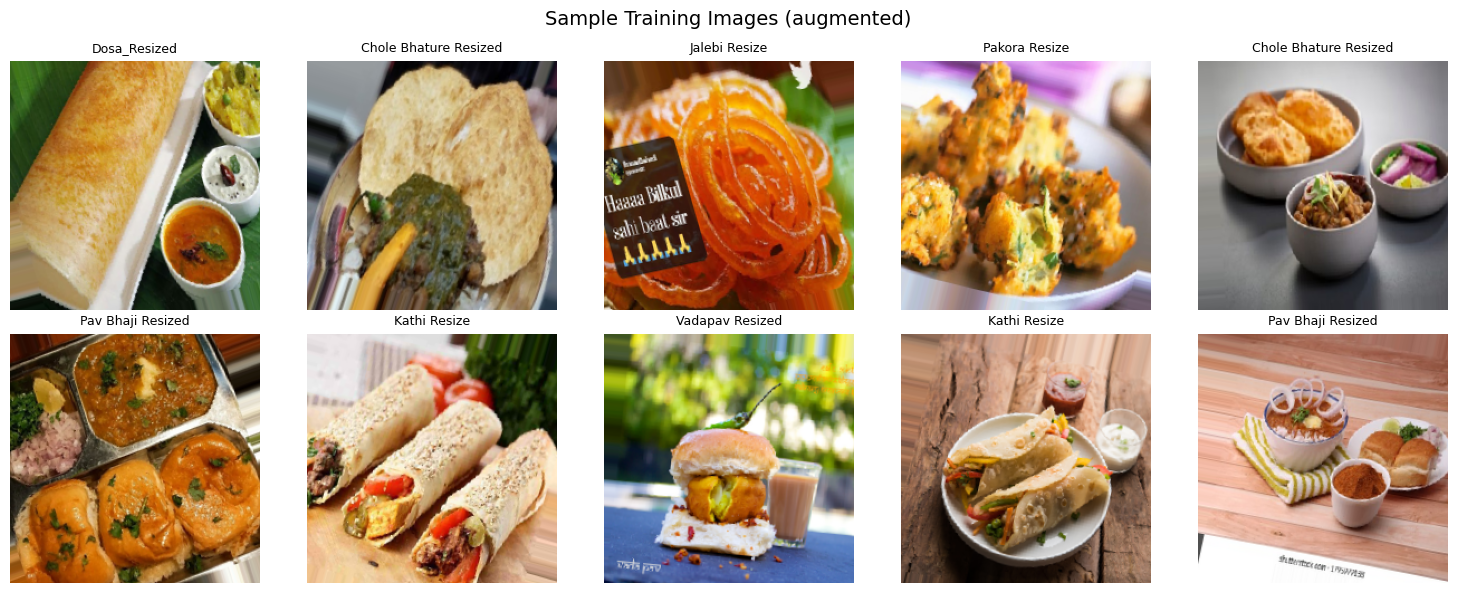

Image shape: (224, 224, 3)
Pixel range: min=-1.000  max=0.997
Expected range: approx [-1.0, 1.0]


In [ ]:
# Cell 9 — Visualise a sample training batch
sample_images, sample_labels = next(train_data)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Training Images (augmented)', fontsize=14)

for i, ax in enumerate(axes.flat):
    # Reverse preprocess_input: [-1,1] → [0,1] for display
    img = np.clip((sample_images[i] + 1.0) / 2.0, 0, 1)
    label_idx = np.argmax(sample_labels[i])
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[label_idx].replace('-', ' ').title(), fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()
print('Image shape:', sample_images[0].shape)
print('Pixel range: min={:.3f}  max={:.3f}'.format(
    sample_images[0].min(), sample_images[0].max()))
print('Expected range: approx [-1.0, 1.0]')


In [ ]:
# Cell 10 — Build MobileNetV2 model
base_model = MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False   # Freeze all base layers for Phase 1

# Classification head
x      = base_model.output
x      = layers.GlobalAveragePooling2D()(x)
x      = layers.Dense(256, activation='relu')(x)
x      = layers.Dropout(0.3)(x)
output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable   = sum(tf.size(v).numpy() for v in model.trainable_variables)
untrainable = sum(tf.size(v).numpy() for v in model.non_trainable_variables)
print(f'Trainable params  : {trainable:,}')
print(f'Frozen params     : {untrainable:,}')
print(f'Total params      : {trainable + untrainable:,}')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Trainable params  : 331,791
Frozen params     : 2,257,986
Total params      : 2,589,777


In [ ]:
# Cell 11 — Training callbacks
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_food_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print('Callbacks ready:')
for cb in callbacks:
    print(f'  {cb.__class__.__name__}')


Callbacks ready:
  EarlyStopping
  ModelCheckpoint
  ReduceLROnPlateau


In [ ]:
# Cell 12 — Phase 1: Train classifier head (base model frozen)
print('=' * 50)
print('PHASE 1: Training classifier head (base frozen)')
print('=' * 50)
history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=2,              # 🔥 reduce epochs
    steps_per_epoch=50,    # 🔥 limit training steps
    validation_steps=20,   # 🔥 limit validation
    callbacks=callbacks
)


best_acc = max(history1.history['val_accuracy'])
print(f'\nPhase 1 complete. Best val_accuracy: {best_acc:.4f}')


PHASE 1: Training classifier head (base frozen)
Epoch 1/2
17/50 ━━━━━━━━━━━━━━━━━━━━ 3:37 7s/step - accuracy: 0.1429 - loss: 3.0401

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.2720 - loss: 2.4939
Epoch 1: val_accuracy improved from None to 0.88437, saving model to best_food_model.keras

Epoch 1: finished saving model to best_food_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 494s 10s/step - accuracy: 0.4137 - loss: 1.9389 - val_accuracy: 0.8844 - val_loss: 0.6195 - learning_rate: 0.0010
Epoch 2/2
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7088 - loss: 0.9859
Epoch 2: val_accuracy improved from 0.88437 to 0.89375, saving model to best_food_model.keras

Epoch 2: finished saving model to best_food_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 256s 5s/step - accuracy: 0.7063 - loss: 0.9860 - val_accuracy: 0.8938 - val_loss: 0.4857 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 2.

Phase 1 complete. Best val_accuracy: 0.8938


In [ ]:
# FIX: entirely new — original notebook never fine-tuned
print('=' * 50)
print('PHASE 2: Fine-tuning top MobileNetV2 layers')
print('=' * 50)

base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

fine_tuned = sum(1 for l in base_model.layers if l.trainable)
print(f'Layers unfrozen in base model: {fine_tuned}')

# Much lower lr to avoid overwriting pretrained weights
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
EPOCHS_FINE = 1
history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=2,              # 🔥 reduce epochs here
    steps_per_epoch=50,    # 🔥 add this line
    validation_steps=20,   # 🔥 optional but good
    callbacks=callbacks
)
best_acc = max(history2.history['val_accuracy'])
print(f'Phase 2 complete. Best val_accuracy: {best_acc:.4f}')

PHASE 2: Fine-tuning top MobileNetV2 layers
Layers unfrozen in base model: 30
Epoch 1/2
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4359 - loss: 1.7287
Epoch 1: val_accuracy improved from 0.89375 to 0.90625, saving model to best_food_model.keras

Epoch 1: finished saving model to best_food_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 236s 4s/step - accuracy: 0.4875 - loss: 1.5761 - val_accuracy: 0.9062 - val_loss: 0.4021 - learning_rate: 1.0000e-05
Epoch 2/2
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5276 - loss: 1.3889
Epoch 2: val_accuracy improved from 0.90625 to 0.91562, saving model to best_food_model.keras

Epoch 2: finished saving model to best_food_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 168s 3s/step - accuracy: 0.5688 - loss: 1.3179 - val_accuracy: 0.9156 - val_loss: 0.3644 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 2.
Phase 2 complete. Best val_accuracy: 0.9156


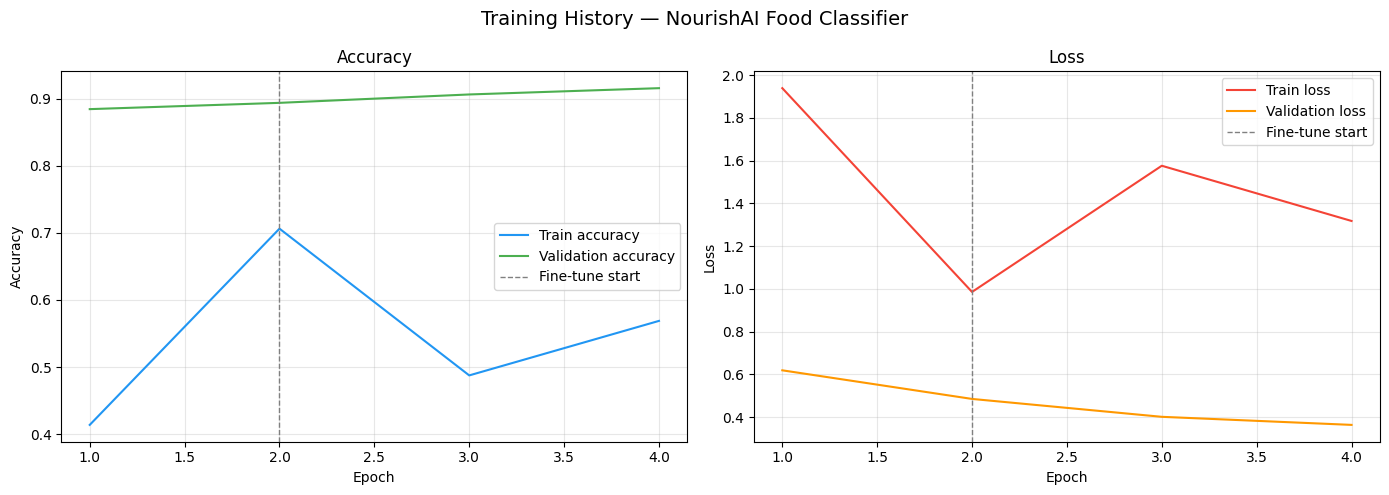

In [ ]:
# Cell 14 — Plot combined Phase 1 + Phase 2 training history
acc      = history1.history['accuracy']     + history2.history['accuracy']
val_acc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss     = history1.history['loss']         + history2.history['loss']
val_loss = history1.history['val_loss']     + history2.history['val_loss']
epochs_r = range(1, len(acc) + 1)
p1_end   = len(history1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History — NourishAI Food Classifier', fontsize=14)

ax1.plot(epochs_r, acc,     label='Train accuracy',      color='#2196F3')
ax1.plot(epochs_r, val_acc, label='Validation accuracy', color='#4CAF50')
ax1.axvline(p1_end, color='gray', linestyle='--', linewidth=1,
            label='Fine-tune start')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_r, loss,     label='Train loss',      color='#F44336')
ax2.plot(epochs_r, val_loss, label='Validation loss', color='#FF9800')
ax2.axvline(p1_end, color='gray', linestyle='--', linewidth=1,
            label='Fine-tune start')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Cell 15 — Evaluate on validation set
val_loss_score, val_acc_score = model.evaluate(val_data, verbose=1)
print(f'Validation Loss    : {val_loss_score:.4f}')
print(f'Validation Accuracy: {val_acc_score:.4f}  ({val_acc_score*100:.1f}%)')

# Sample predictions on first 10 validation images
val_data.reset()
sample_imgs, sample_true = next(val_data)
preds = model.predict(sample_imgs[:10], verbose=0)

print('\nSample predictions (first 10 images):')
print(f'{"True Label":<30} {"Predicted":<30} Confidence')
print('-' * 70)
for i in range(10):
    true_idx  = np.argmax(sample_true[i])
    pred_idx  = np.argmax(preds[i])
    conf      = preds[i][pred_idx] * 100
    true_name = CLASS_NAMES[true_idx].replace('-', ' ').title()
    pred_name = CLASS_NAMES[pred_idx].replace('-', ' ').title()
    match     = '✓' if true_idx == pred_idx else '✗'
    print(f'{match}  {true_name:<28} {pred_name:<30} {conf:.1f}%')


60/60 ━━━━━━━━━━━━━━━━━━━━ 253s 4s/step - accuracy: 0.8095 - loss: 0.6080
Validation Loss    : 0.6080
Validation Accuracy: 0.8095  (80.9%)

Sample predictions (first 10 images):
True Label                     Predicted                      Confidence
----------------------------------------------------------------------
✓  Biryani Resize               Biryani Resize                 70.6%
✓  Biryani Resize               Biryani Resize                 90.5%
✓  Biryani Resize               Biryani Resize                 95.8%
✓  Biryani Resize               Biryani Resize                 97.2%
✓  Biryani Resize               Biryani Resize                 99.6%
✓  Biryani Resize               Biryani Resize                 80.5%
✓  Biryani Resize               Biryani Resize                 99.2%
✓  Biryani Resize               Biryani Resize                 95.2%
✓  Biryani Resize               Biryani Resize                 79.7%
✓  Biryani Resize               Biryani Resize           

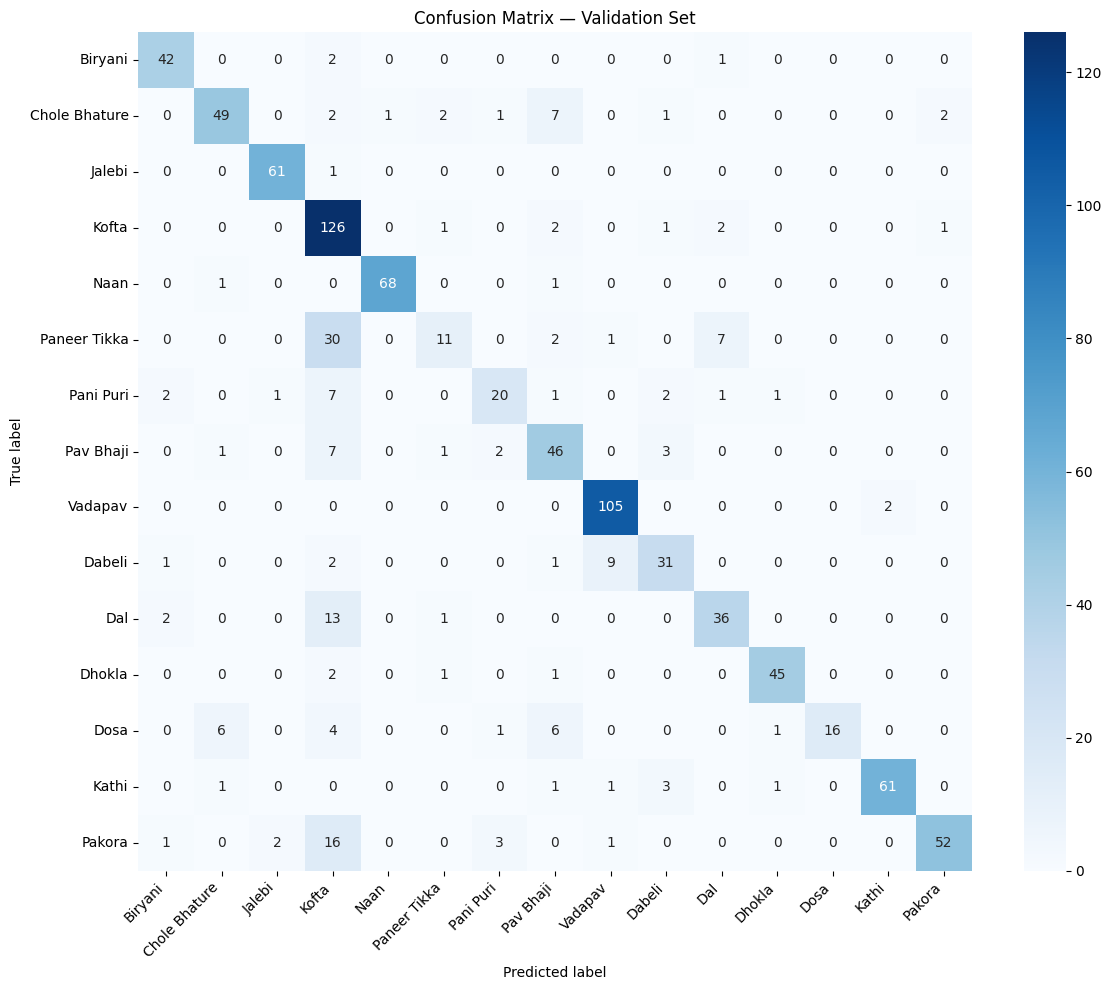

Classification Report:
               precision    recall  f1-score   support

      Biryani       0.88      0.93      0.90        45
Chole Bhature       0.84      0.75      0.80        65
       Jalebi       0.95      0.98      0.97        62
        Kofta       0.59      0.95      0.73       133
         Naan       0.99      0.97      0.98        70
 Paneer Tikka       0.65      0.22      0.32        51
    Pani Puri       0.74      0.57      0.65        35
    Pav Bhaji       0.68      0.77      0.72        60
      Vadapav       0.90      0.98      0.94       107
       Dabeli       0.76      0.70      0.73        44
          Dal       0.77      0.69      0.73        52
       Dhokla       0.94      0.92      0.93        49
         Dosa       1.00      0.47      0.64        34
        Kathi       0.97      0.90      0.93        68
       Pakora       0.95      0.69      0.80        75

     accuracy                           0.81       950
    macro avg       0.84      0.77      

In [ ]:
# Cell 16 — Confusion matrix and classification report
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

val_data.reset()
y_true, y_pred = [], []
for _ in range(len(val_data)):
    imgs, labels = next(val_data)
    preds_batch  = model.predict(imgs, verbose=0)
    y_true.extend(np.argmax(labels,      axis=1))
    y_pred.extend(np.argmax(preds_batch, axis=1))

# Clean class names for display
clean = [re.sub(r'[-_]re?sized?', '', n, flags=re.IGNORECASE)
         .replace('-', ' ').replace('_', ' ').title()
         for n in CLASS_NAMES]

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=clean, yticklabels=clean)
plt.title('Confusion Matrix — Validation Set')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=clean))


In [ ]:
# Cell 17 — Save the final model as food_model.h5


model.save('food_model.h5')
print('✅ Model saved: food_model.h5')

size = os.path.getsize('food_model.h5') / (1024 * 1024)
print(f'Final model size: {size:.1f} MB')

if os.path.exists('best_food_model.h5'):
    size2 = os.path.getsize('best_food_model.h5') / (1024 * 1024)
    print(f'Best checkpoint : best_food_model.h5 ({size2:.1f} MB)')


✅ Model saved: food_model.h5
Final model size: 24.6 MB


In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model('food_model.h5', compile=False)
print('✅ Model reloaded successfully')
print(f'Input shape : {loaded_model.input_shape}')
print(f'Output shape: {loaded_model.output_shape}  (should be (None, {NUM_CLASSES}))')

# Use dynamic size
dummy = np.zeros((1, IMG_SIZE[0], IMG_SIZE[1], 3), dtype=np.float32)

out = loaded_model.predict(dummy, verbose=0)
print(f'Dummy output shape: {out.shape}')
print(f'Sum of probs      : {out.sum():.6f}  (should be ~1.0)')

print('\n✅ Model is ready — place food_model.h5 next to app.py')

✅ Model reloaded successfully
Input shape : (None, 224, 224, 3)
Output shape: (None, 15)  (should be (None, 15))
Dummy output shape: (1, 15)
Sum of probs      : 1.000000  (should be ~1.0)

✅ Model is ready — place food_model.h5 next to app.py


In [ ]:
# Cell 19 — Interactive single-image test
# FIX: uses preprocess_input (not /255.0) — must match training preprocessing

from google.colab import files
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

uploaded = files.upload()

for filename in uploaded.keys():
    img = Image.open(filename).convert('RGB')

    # CORRECT preprocessing — same as training pipeline
    img_resized = img.resize((224, 224))
    img_array   = np.array(img_resized).astype('float32')
    img_array   = preprocess_input(img_array)          # ← scales to [-1, 1]
    img_array   = np.expand_dims(img_array, axis=0)

    pred        = loaded_model.predict(img_array, verbose=0)
    class_index = np.argmax(pred)
    confidence  = pred[0][class_index] * 100

    clean_name  = re.sub(r'[-_]re?sized?', '', CLASS_NAMES[class_index],
                         flags=re.IGNORECASE).replace('-',' ').title()

    print(f'\nFile         : {filename}')
    print(f'Predicted    : {clean_name}  (class index {class_index})')
    print(f'Confidence   : {confidence:.1f}%')
    print('Top-3 predictions:')
    top3 = np.argsort(pred[0])[::-1][:3]
    for rank, idx in enumerate(top3, 1):
        name = re.sub(r'[-_]re?sized?', '', CLASS_NAMES[idx],
                      flags=re.IGNORECASE).replace('-',' ').title()
        print(f'  {rank}. {name:<25} {pred[0][idx]*100:.1f}%')

    # OCR nutrition label (if the image contains one)
    text   = extract_text(img)
    parsed = extract_nutrition_info(text)
    if text.strip():
        print(f'\nOCR text   :\n{text}')
    if parsed:
        print(f'Parsed info: {parsed}')


In [ ]:
# Cell 20 — Download food_model.h5 to your local machine
from google.colab import files
files.download('food_model.h5')
print('Download started.')
print('Next step: place food_model.h5 next to app.py and run:')
print('streamlit run app.py')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
Next step: place food_model.h5 next to app.py and run:
streamlit run app.py


In [ ]:
from google.colab import files
uploaded = files.upload()

for filename in uploaded.keys():
    img = Image.open(filename).convert("RGB")

    # preprocess
    img_resized = img.resize((128, 128))
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # prediction
    pred = loaded_model.predict(img_array)
    class_index = np.argmax(pred)

    print("Predicted class index:", class_index)

    # OCR
    text = extract_text(img)
    print("Extracted Text:\n", text)

    # NLP ✅ (NOW CORRECTLY CALLED)
    parsed = extract_nutrition_info(text)
    print("Parsed Info:", parsed)

In [ ]:
import tensorflow as tf

# Load your model WITHOUT safe mode restrictions
model = tf.keras.models.load_model("best_food_model.keras", compile=False)

# Rebuild model architecture cleanly
model = tf.keras.models.clone_model(model)
model.set_weights(model.get_weights())

# Save clean version (no quantization_config)
model.save("clean_food_model.h5")

print("✅ Clean model saved!")

✅ Clean model saved!


In [ ]:
from google.colab import files
files.download('food_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
print(os.listdir())

['.config', 'drive', 'food_model.h5', 'best_food_model.keras', 'clean_food_model.h5', 'sample_data']
